# Network Traffic Congestion Prediction

## Problem Statement
The goal of this project is to predict whether a network will experience congestion in the near future using network traffic flow data.

Congestion prediction helps in proactive bandwidth management and maintaining service quality.

## Approach Overview

- The dataset contains flow-level network data.
- However, congestion is a network-level phenomenon.
- Therefore, I aggregated flows into time windows to represent network state.

Steps:
1. Chunk-based data processing for scalability
2. Time-window aggregation (1-minute)
3. Feature engineering (traffic + temporal features)
4. Label creation using percentile-based threshold
5. Model training and evaluation
6. Reformulation to predict future congestion

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CHUNK_SIZE = 100000
file_path = "Dataset-Unicauca-Version2-87Atts.csv"

chunk_iter = pd.read_csv(file_path, chunksize=CHUNK_SIZE)

The dataset is large, so chunk-based processing is used to ensure memory efficiency and scalability.

In [2]:
# Data preprocessing and aggregation
def process_chunk(chunk):
    
    # Fix timestamp
    chunk['Timestamp'] = chunk['Timestamp'].str.replace(
        r'(\d{4})(\d{2}:)', r'\1 \2', regex=True
    )
    chunk['Timestamp'] = pd.to_datetime(
        chunk['Timestamp'], format='%d/%m/%Y %H:%M:%S'
    )
    
    # Sort
    chunk = chunk.sort_values('Timestamp')
    
    # Per-flow features
    chunk['total_bytes'] = (
        chunk['Total.Length.of.Fwd.Packets'] +
        chunk['Total.Length.of.Bwd.Packets']
    )
    
    chunk['total_packets'] = (
        chunk['Total.Fwd.Packets'] +
        chunk['Total.Backward.Packets']
    )
    
    # Time window
    chunk['time_window'] = chunk['Timestamp'].dt.floor('1min')
    
    # Aggregation
    agg = chunk.groupby('time_window').agg({
        'total_bytes': 'sum',
        'total_packets': 'sum',
        'Flow.Duration': 'mean',
        'Flow.ID': 'count'
    }).rename(columns={'Flow.ID': 'num_flows'}).reset_index()
    
    return agg

In [3]:
# Combining chunks
aggregated_data = []

for chunk in pd.read_csv(file_path, chunksize=100000):
    agg_chunk = process_chunk(chunk)
    aggregated_data.append(agg_chunk)

df_agg = pd.concat(aggregated_data, ignore_index=True)

df_agg = df_agg.groupby('time_window').sum().reset_index()

df_agg['Flow.Duration'] = df_agg['Flow.Duration'] / df_agg['num_flows']

In [4]:
# Feature engineering
df_agg['bytes_per_sec'] = df_agg['total_bytes'] / 60
df_agg['packets_per_sec'] = df_agg['total_packets'] / 60
df_agg['flows_per_sec'] = df_agg['num_flows'] / 60

df_agg['avg_packet_size'] = (
    df_agg['total_bytes'] / df_agg['total_packets']
)

df_agg = df_agg.sort_values('time_window')

# Rolling features
df_agg['bytes_rolling_mean'] = df_agg['total_bytes'].rolling(3).mean()
df_agg['bytes_rolling_std'] = df_agg['total_bytes'].rolling(3).std()

df_agg = df_agg.fillna(0)

<Axes: xlabel='time_window'>

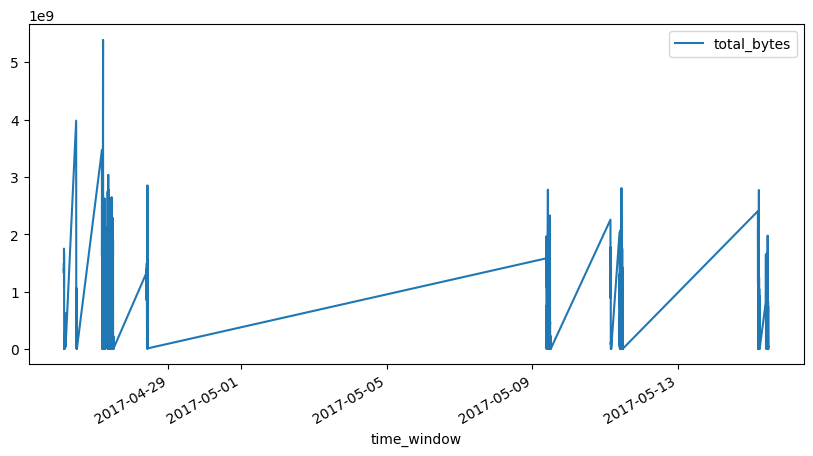

In [5]:
# Visualization
df_agg.plot(x='time_window', y='total_bytes', figsize=(10,5))

<Axes: >

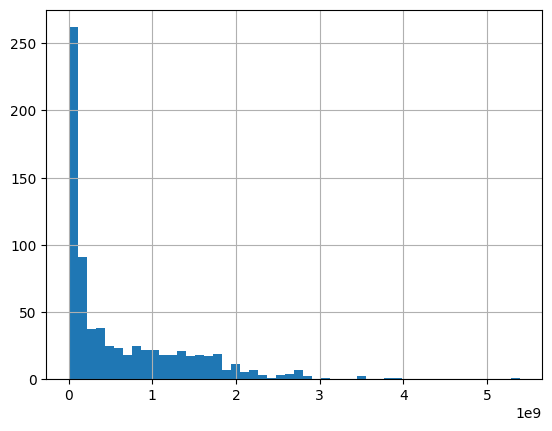

In [6]:
df_agg['total_bytes'].hist(bins=50)

In [7]:
# Label creation
threshold = df_agg['total_bytes'].quantile(0.90)

df_agg['congested'] = (df_agg['total_bytes'] > threshold).astype(int)

df_agg['congested'].value_counts(normalize=True)

congested
0    0.899598
1    0.100402
Name: proportion, dtype: float64

Congestion is defined as the top 10% of traffic windows based on total bytes.

In [8]:
# Baseline model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

split_index = int(len(df_agg) * 0.8)

train_df = df_agg.iloc[:split_index]
test_df = df_agg.iloc[split_index:]

features = ['total_bytes', 'total_packets', 'num_flows']

model = RandomForestClassifier(random_state=42)
model.fit(train_df[features], train_df['congested'])

y_pred = model.predict(test_df[features])

print("Accuracy:", accuracy_score(test_df['congested'], y_pred))

Accuracy: 1.0


In [9]:
# Feature importance
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

total_bytes      0.563709
total_packets    0.336731
num_flows        0.099560
dtype: float64


This baseline shows very high accuracy due to label-feature correlation.

In [10]:
# Final model (Future Prediction)
# Creating shifted targets
df_agg = df_agg.sort_values('time_window')

df_agg['congested_next'] = df_agg['congested'].shift(-1)

df_agg = df_agg.dropna()

In [11]:
# Performing train-test split (time based)
split_index = int(len(df_agg) * 0.8)

train_df = df_agg.iloc[:split_index]
test_df = df_agg.iloc[split_index:]

In [12]:
# Defining label and features
target = 'congested_next'

features = [
    'total_bytes', 'total_packets', 'num_flows',
    'bytes_per_sec', 'packets_per_sec', 'flows_per_sec',
    'avg_packet_size', 'bytes_rolling_mean', 'bytes_rolling_std'
]

In [13]:
# Training with class weights
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model.fit(train_df[features], train_df[target])

y_pred = model.predict(test_df[features])

In [14]:
# Evaluation
from sklearn.metrics import classification_report

print(classification_report(test_df[target], y_pred))

              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       142
         1.0       0.50      0.38      0.43         8

    accuracy                           0.95       150
   macro avg       0.73      0.68      0.70       150
weighted avg       0.94      0.95      0.94       150



<Axes: >

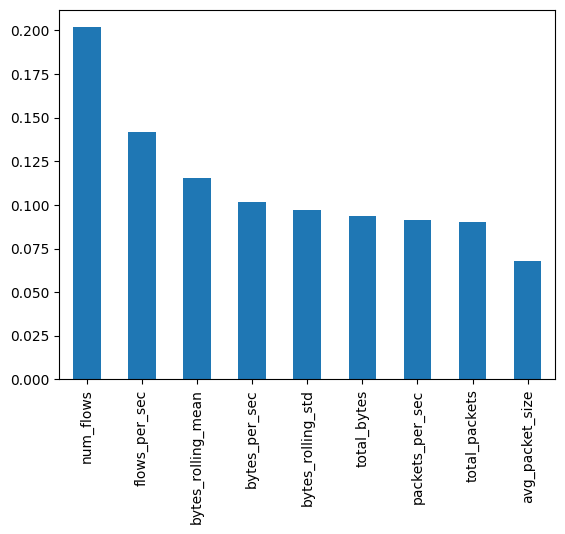

In [15]:
# Feature Importance
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance.plot(kind='bar')

In [ ]:
# Saving the model
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

## Conclusion

- The model successfully predicts future congestion using aggregated network features.
- Temporal features play a key role in prediction.
- Predicting congestion is challenging due to its rare and dynamic nature.
- The model performs well but recall can be improved further.